In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Task 1: Linear Regression with Non-Linear Basis Functions

In [2]:
N = 100
x = np.random.uniform(0,20,N)
epsilon = np.random.normal(0,1,N)
def true_func(x):
    return np.sin(np.sqrt(x))+np.cos(x)+np.sin(x)
y = true_func(x)
y_noisy = y + epsilon

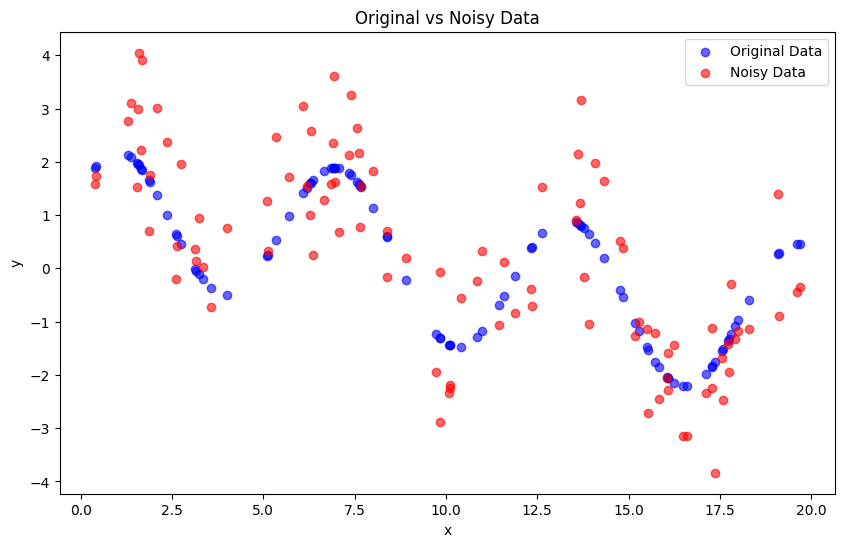

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Original Data', color='blue', alpha=0.6)
plt.scatter(x, y_noisy, label='Noisy Data', color='red', alpha=0.6)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Original vs Noisy Data')
plt.legend()
plt.show()

In [14]:
x_plot = np.linspace(0, 20, 1000) # define x for plotting

def gaussian_func(x, mu, sigma=1):
    return np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

def gen_gaussian_basis(x, D, sigma=1):
    mu = np.linspace(0, 20, D)  
    basis_functions = np.array([gaussian_func(x, m, sigma) for m in mu]) 
    return basis_functions

# Plot Gaussian basis functions
def plot_gaussian_basis(x, D, sigma=1):
    basis_functions = gen_gaussian_basis(x, D, sigma)
    plt.figure(figsize=(10, 6))
    
    for i in range(D):
        plt.plot(x, basis_functions[i], label=f'μ={np.linspace(0, 20, D)[i]:.2f}')
    
    plt.xlabel('x')
    plt.ylabel('Basis Function Value')
    plt.title(f'Gaussian Basis Functions (D={D})')
    plt.grid(True)
    plt.show()


D_values = list(range(0, 110, 10))
# for D in D_values:
#     if D > 0:  
#         plot_gaussian_basis(x_plot, D)


In [15]:
class LinearRegression():
    def __init__(self, add_bias=True):
        self.add_bias = add_bias
    def fit(self, X, y):
        if self.add_bias:
            X = np.hstack([np.ones((X.shape[0], 1)), X])
        self.coefficients = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
        return self

    def predict(self, X):
        if self.add_bias:
            X = np.hstack([np.ones((X.shape[0], 1)), X])
        return X.dot(self.coefficients)

    def errors(self, error_func,x, y):
        yh = self.predict(x)
        self.error = error_func(yh, y)
        return self.error

In [16]:
def gen_X_matrix(x, D):
    X = np.zeros((len(x),D))
    for i, num in enumerate(x):
        X[i,:] = gen_gaussian_basis(num, D)
    return X

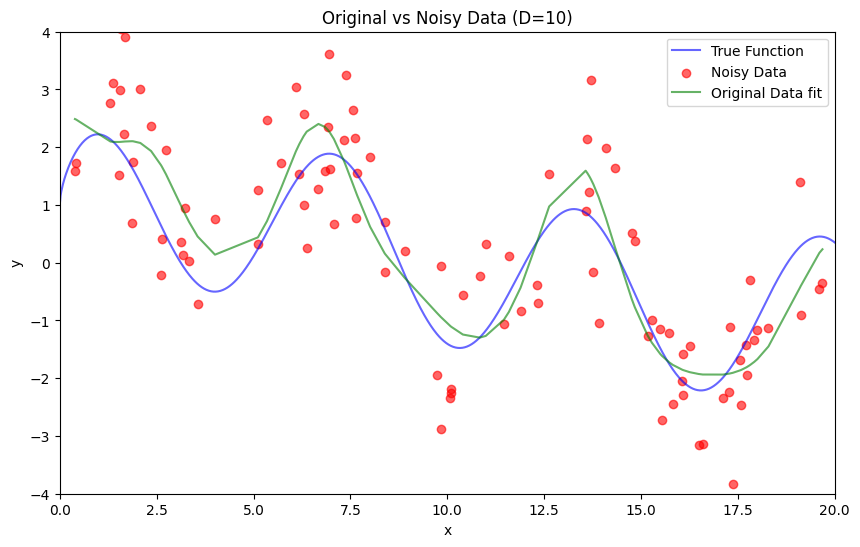

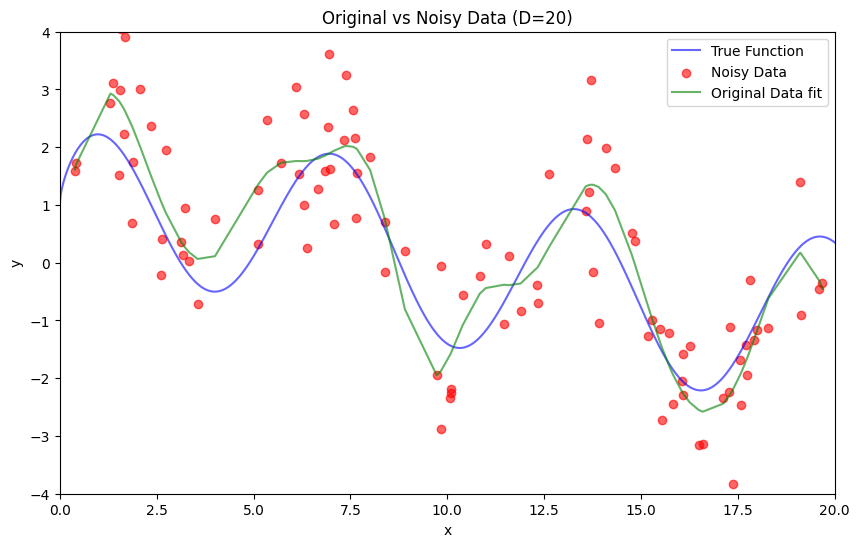

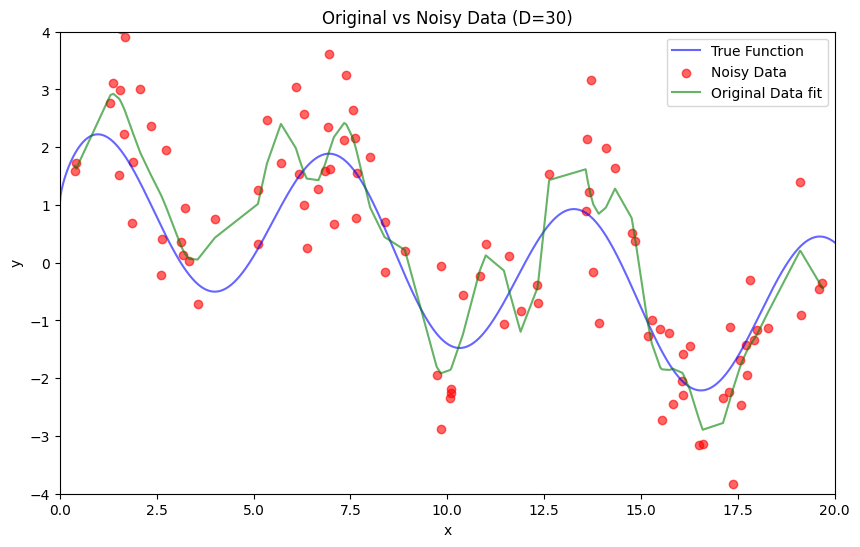

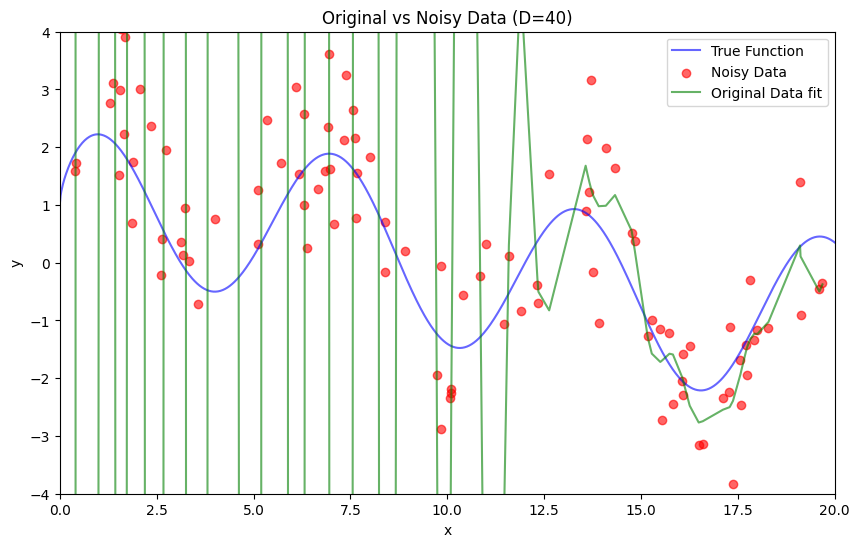

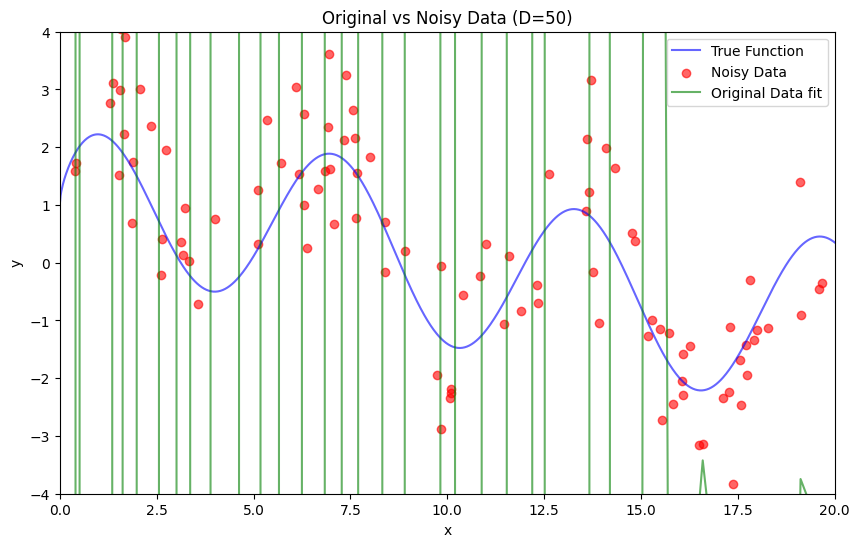

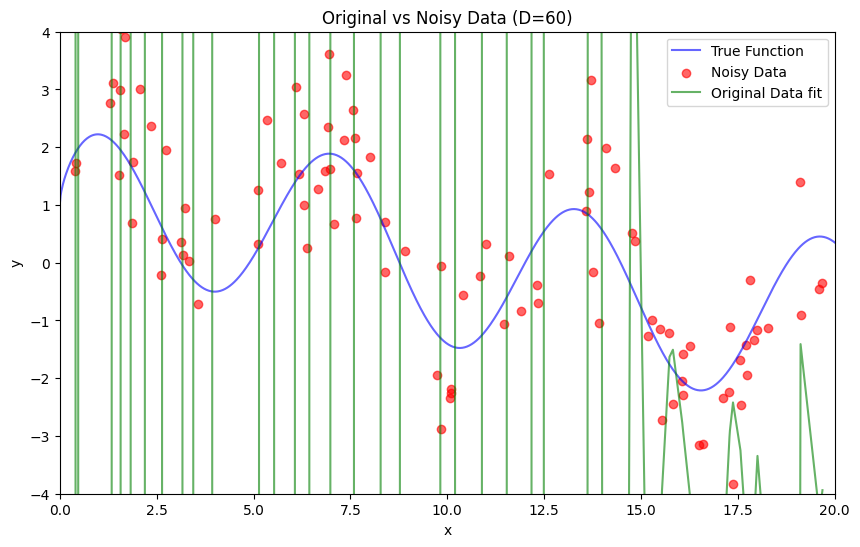

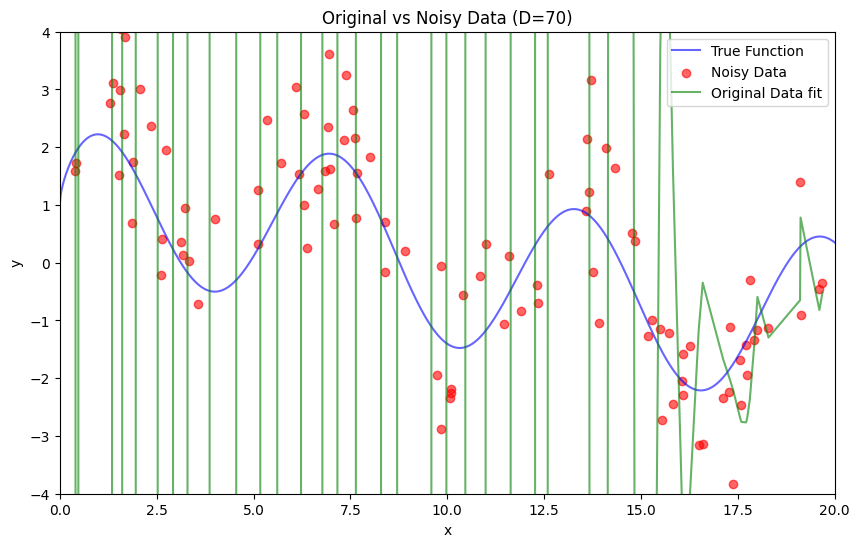

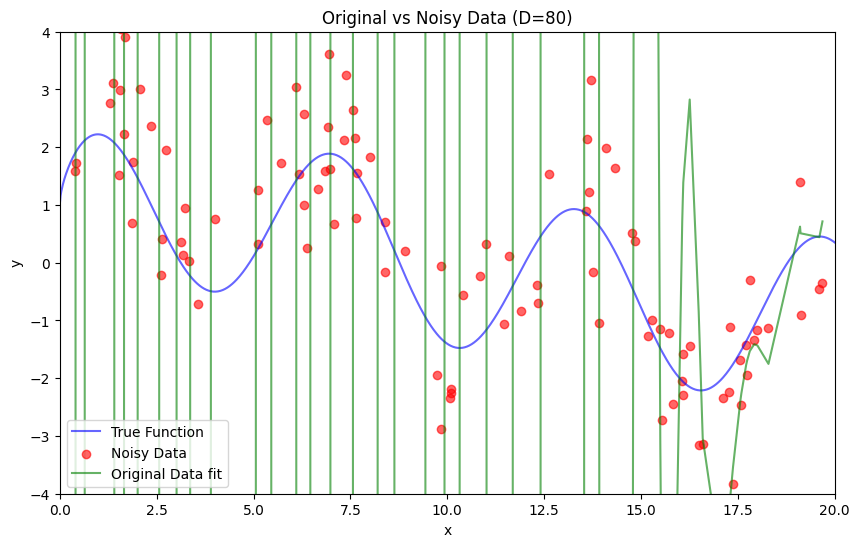

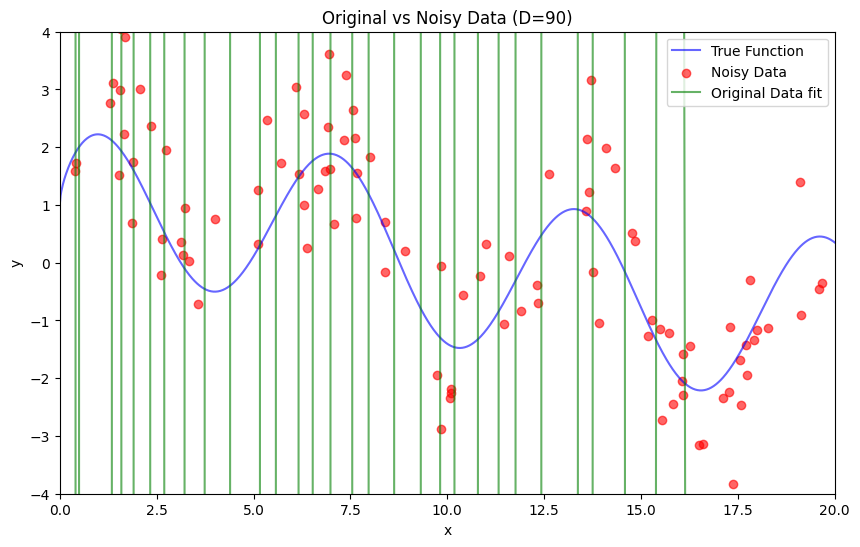

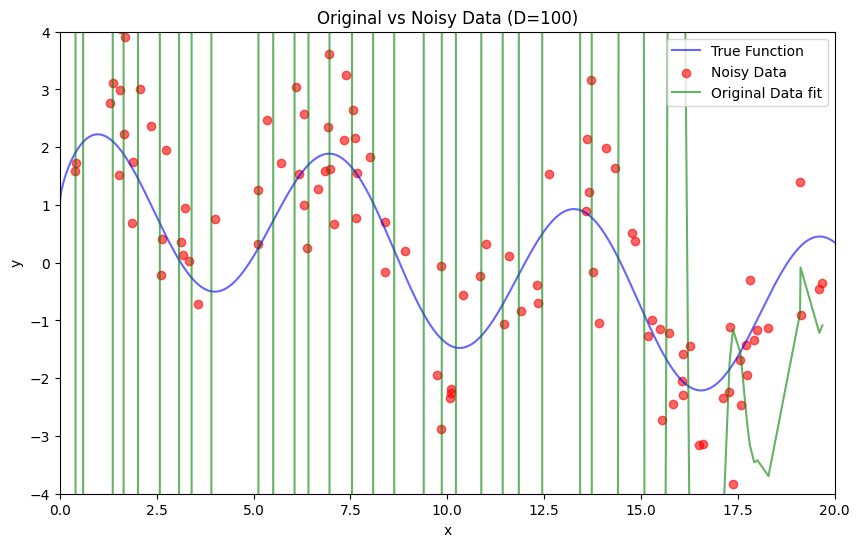

In [18]:
for D in D_values:
    if D > 0:
        model = LinearRegression()
        X = gen_X_matrix(x, D)
        model.fit(X, y_noisy)

        # X_plot = np.zeros((len(x_plot),D))
        # for i, num in enumerate(x_plot):
        #     X_plot[i] = gen_gaussian_basis(num, D)
        # y_pred_smooth = model.predict(X_plot)

        X_sorted = gen_X_matrix(sorted(x), D)
        y_pred = model.predict(X_sorted)

        plt.figure(figsize=(10, 6))
        plt.plot(x_plot, true_func(x_plot), label='True Function', color='blue', alpha=0.6)
        plt.scatter(x, y_noisy, label='Noisy Data', color='red', alpha=0.6)
        # plt.plot(x_plot, y_pred_smooth, label='Predicted Data', color='green')
        plt.plot(sorted(x), y_pred, label='Original Data fit', color='green', alpha=0.6)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.xlim([0, 20])
        plt.ylim([-4, 4])
        plt.legend()
        plt.title(f'Original vs Noisy Data (D={D})')

In [8]:
from sklearn.model_selection import train_test_split

In [19]:
x_train, x_vaild, y_train, y_vaild = train_test_split(x, y_noisy, test_size=0.4, random_state=42)
for D in D_values:
    if D > 0:
        X_train = gen_X_matrix(x_train, D)
        X_vaild = gen_X_matrix(x_vaild, D)

        model_selec = LinearRegression()
        model_selec.fit(X_train, y_train)

        def sse(yh, y):
            return np.sum((yh - y) ** 2)
        print('\nNumber of gaussian basis: ', D)
        print('SSE of training set: ', model_selec.errors(sse, X_train, y_train))
        print('SSE of vaild set: ', model_selec.errors(sse, X_vaild, y_vaild))


Number of gaussian basis:  10
SSE of training set:  64.8522033193659
SSE of vaild set:  45.260811381664055

Number of gaussian basis:  20
SSE of training set:  35.4926818159415
SSE of vaild set:  830.1173973807416

Number of gaussian basis:  30
SSE of training set:  21.992583390819476
SSE of vaild set:  83383.72074703858

Number of gaussian basis:  40
SSE of training set:  55074783.276247606
SSE of vaild set:  27958489046.206078

Number of gaussian basis:  50
SSE of training set:  7812509954468517.0
SSE of vaild set:  4.953912035135184e+19

Number of gaussian basis:  60
SSE of training set:  990928794334680.8
SSE of vaild set:  7.159018314996099e+17

Number of gaussian basis:  70
SSE of training set:  8.90590245909106e+17
SSE of vaild set:  2.480131201615121e+22

Number of gaussian basis:  80
SSE of training set:  258151996527717.3
SSE of vaild set:  1.0038569829456548e+19

Number of gaussian basis:  90
SSE of training set:  3.6976895797452525e+17
SSE of vaild set:  7.537628878055027e

### Task 2: Bias-Variance Tradeoff with Multiple Fits

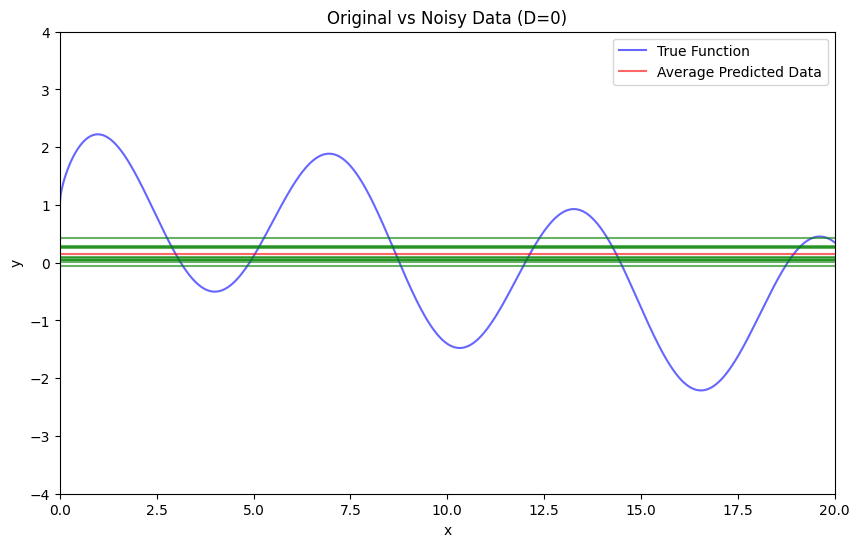

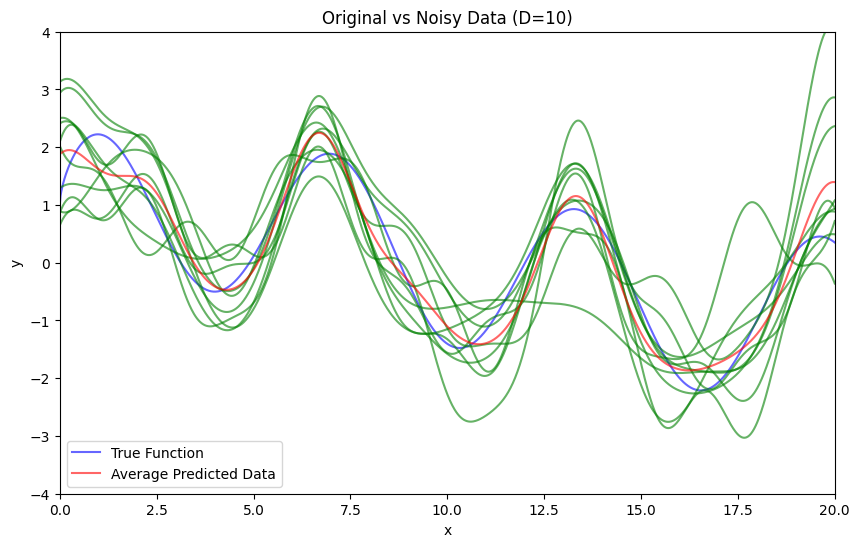

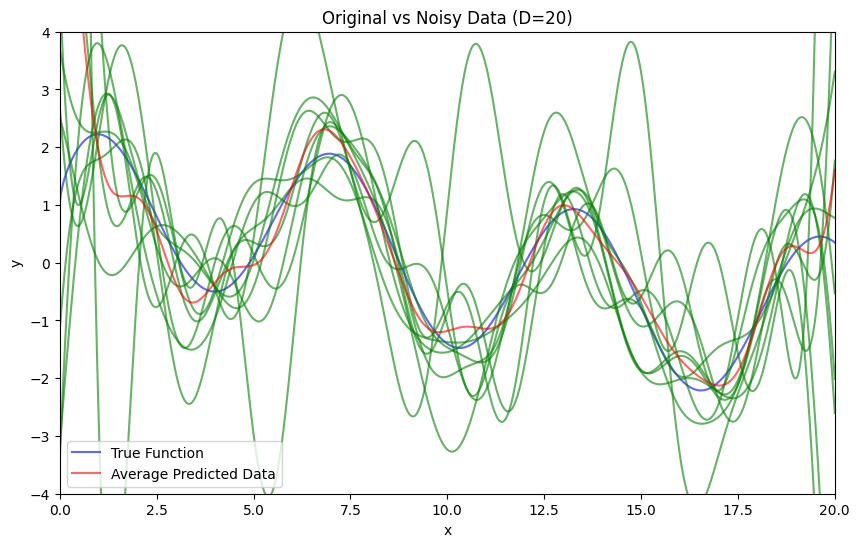

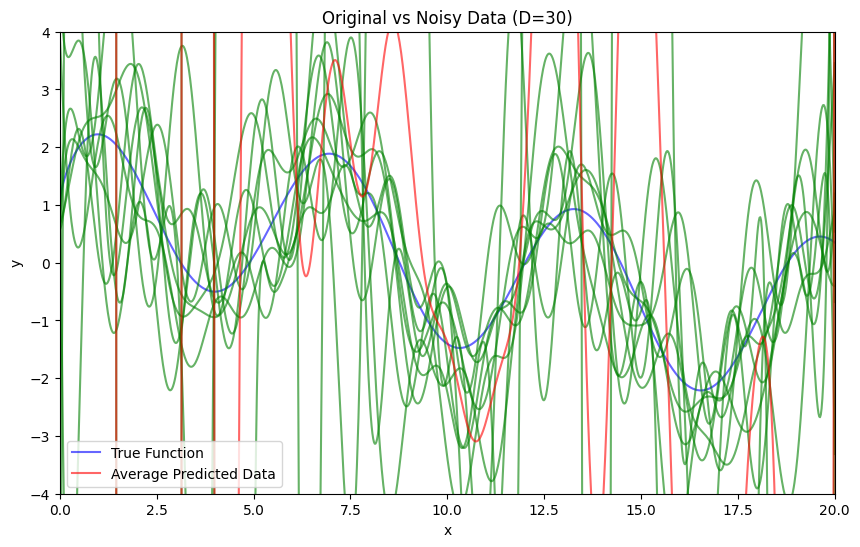

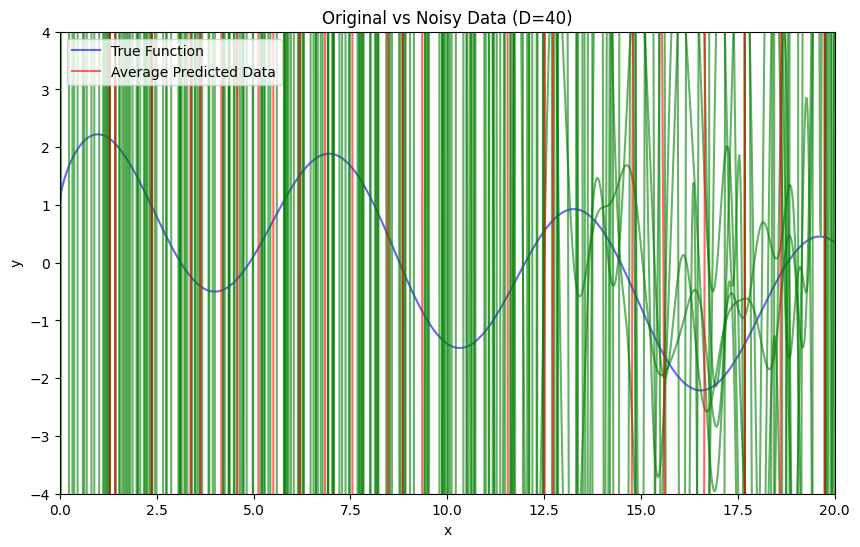

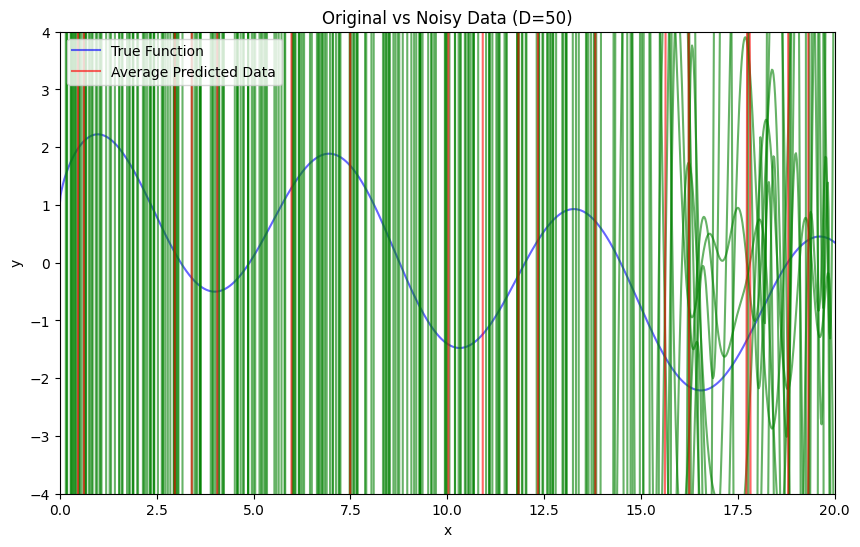

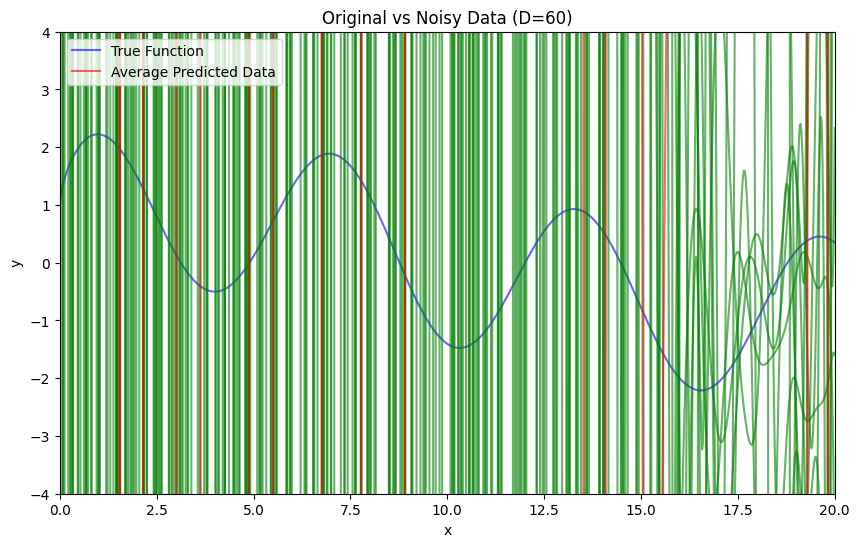

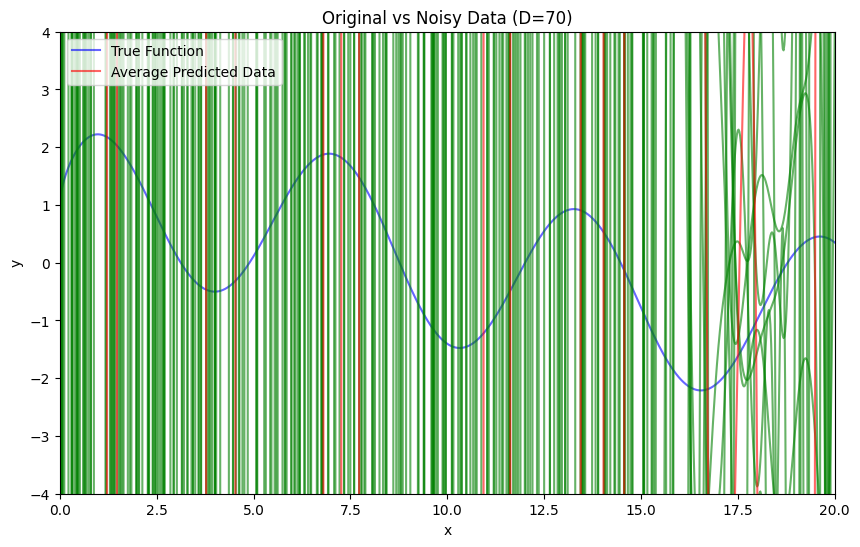

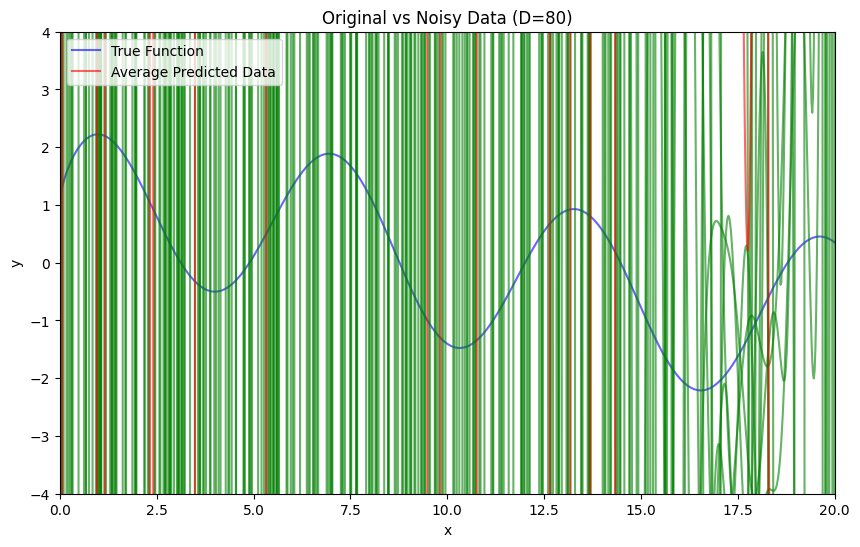

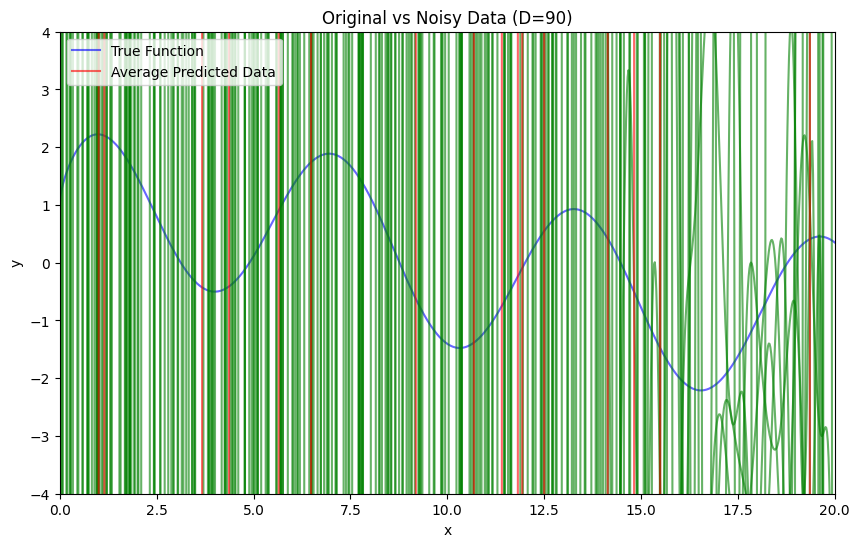

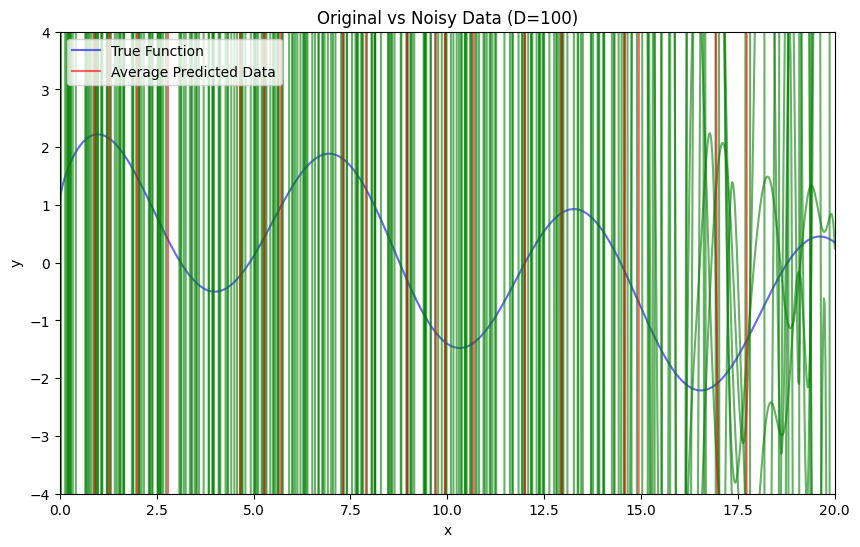

In [25]:
train_error_avg = []
test_error_avg = []
for D in D_values:
    model_set = []
    train_error = []
    test_error = []
    for i in range(10):
        # regenerate data
        x = np.random.uniform(0,20,N)
        epsilon = np.random.normal(0,1,N)
        def true_func(x):
            return np.sin(np.sqrt(x))+np.cos(x)+np.sin(x)
        y = true_func(x)
        y_noisy = y + epsilon
        x_train, x_test, y_train, y_test = train_test_split(x, y_noisy, test_size=0.5, random_state=42)
        model = LinearRegression()
        X_train = gen_X_matrix(x_train, D)
        model.fit(X_train, y_train)
        model_set.append(model)
        X_test = gen_X_matrix(x_test, D)
        train_error.append(model.errors(sse, X_train, y_train))
        test_error.append(model.errors(sse, X_test, y_test))

    train_error_avg.append(np.mean(train_error))
    test_error_avg.append(np.mean(test_error))
    plt.figure(figsize=(10, 6))
    plt.plot(x_plot, true_func(x_plot), label='True Function', color='blue', alpha=0.6)

    y_pred_sum = 0
    X_plot = gen_X_matrix(x_plot, D)
    for model in model_set:
        y_pred = model.predict(X_plot)
        plt.plot(x_plot, y_pred, color='green', alpha=0.6)
        y_pred_sum += y_pred
    y_pred_avg = y_pred_sum / 10
    plt.plot(x_plot, y_pred_avg, color='red', label='Average Predicted Data', alpha=0.6)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim([0, 20])
    plt.ylim([-4, 4])
    plt.legend()
    plt.title(f'Original vs Noisy Data (D={D})')



        

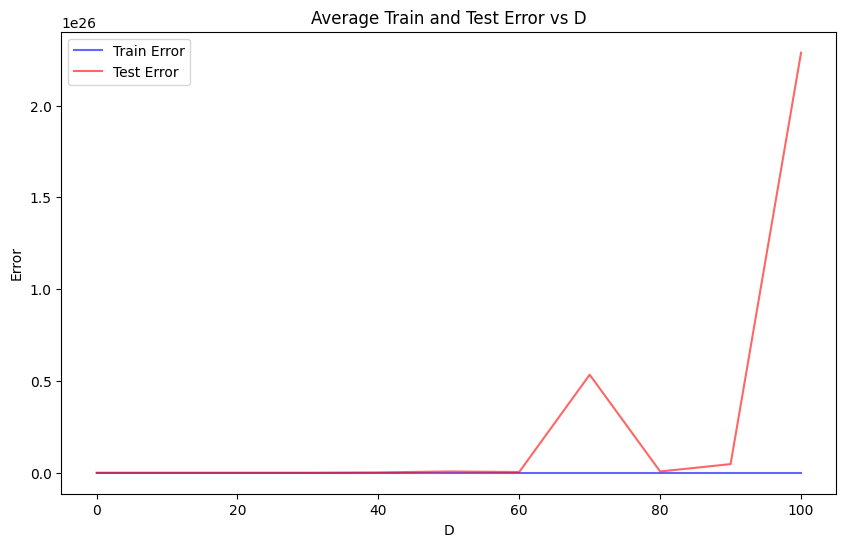

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(D_values, train_error_avg, label='Train Error', color='blue', alpha=0.6)
plt.plot(D_values, test_error_avg, label='Test Error', color='red', alpha=0.6)
plt.xlabel('D')
plt.ylabel('Error')
plt.title('Average Train and Test Error vs D')
plt.legend()
plt.show()


### Task 3: Regularization with Cross-Validation


In [ ]:
cost = lambda w: .5*np.mean((w[0] + w[1]*x - y)**2)
l2_penalty = lambda w: np.dot(w,w)/2
l1_penalty = lambda w: np.sum(np.abs(w))
cost_plus_l2 = lambda w: cost(w) + 5*l2_penalty(w)

In [28]:
class GradientDescent():
    
    def __init__(self, learning_rate=.001, max_iters=1e4, epsilon=1e-8, record_history=False):
        self.learning_rate = learning_rate
        self.max_iters = max_iters
        self.record_history = record_history
        self.epsilon = epsilon
        if record_history:
            self.w_history = []
            
    def run(self, gradient_fn, x, y, w):
        grad = np.inf
        t = 1
        while np.linalg.norm(grad) > self.epsilon and t < self.max_iters:
            grad = gradient_fn(x, y, w)
            w = w - self.learning_rate * grad
            if self.record_history:
                self.w_history.append(w)
            t += 1
        return w
    
class LinearRegression_regularized():
    def __init__(self, regularization, weight, add_bias=True):
        self.add_bias = add_bias
        self.regularization = regularization
        self.weight = weight
            
    def fit(self, x, y, optimizer):
        if x.ndim == 1:
            x = x[:, None]
        if self.add_bias:
            N = x.shape[0]
            x = np.column_stack([x,np.ones(N)])
        N,D = x.shape
        def gradient(x, y, w):
            yh =  x @ w 
            N, D = x.shape
            grad = 0.5*np.dot(yh - y, x)/N
            if self.regularization == 'L2':
                grad += self.weight* w
            if self.regularization == 'L1':
                grad += self.weight * np.sign(w)
            return grad
        w0 = np.zeros(D)
        self.w = optimizer.run(gradient, x, y, w0)
        return self
    
    def predict(self, x):
        if self.add_bias:
            x = np.column_stack([x,np.ones(N)])
        yh = x@self.w
        return yh